Import Dataset and libraries

In [68]:
import pandas as pd

In [69]:
bank = pd.read_csv("data/Churn_Modelling.csv")

Show 5 first rows

In [70]:
bank.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Redundant columns

In [71]:
custom = ["RowNumber", "CustomerId", "Surname"]

In [72]:
bank.drop(custom, axis=1, inplace=True)

EDA

In [73]:
bank.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Checking for missing data

In [74]:
bank.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Data Preprocessing

In [75]:
from sklearn.model_selection import train_test_split

Data Shuffle

In [76]:
bank = bank.sample(frac=1, random_state=225)

In [77]:
X = bank.drop("Exited", axis=1)
y = bank["Exited"]

Data splitting

In [78]:
X_full, X_test, y_full, y_test = train_test_split(X, y, test_size=0.2, random_state=51, stratify=y) # get testing data

X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.125, random_state=51, stratify=y_full) # get testing and training data

In [79]:
X_train.shape, X_test.shape, X_val.shape

((7000, 10), (2000, 10), (1000, 10))

In [80]:
bank = X_train # renaming to bank for personal preferences

In [81]:
numerical = [column for column in bank if bank[column].dtype != "O"]

feature scaling

In [82]:
from sklearn.preprocessing import StandardScaler

In [83]:
scaler = StandardScaler()

In [84]:
scaler.fit(X_train[numerical])

StandardScaler()

In [85]:
bank[numerical] = scaler.transform(bank[numerical])

Feature Encoding

In [86]:
from feature_engine.encoding import OneHotEncoder

In [87]:
encoder = OneHotEncoder()

In [88]:
encoder.fit(bank)

OneHotEncoder()

In [89]:
bank = encoder.transform(bank)

In [90]:
bank.shape

(7000, 13)

Imbalanced Data Handling

In [91]:
from imblearn.over_sampling import SMOTE

In [92]:
smote = SMOTE(sampling_strategy='minority')

In [93]:
X_train, y_train = smote.fit_resample(bank, y_train)

y_train.value_counts()

0    5574
1    5574
Name: Exited, dtype: int64

Data Processing for Validation

In [94]:
X_val[numerical] = scaler.transform(X_val[numerical])
X_val = encoder.transform(X_val)


Data Processing for Testing

In [95]:
X_test[numerical] = scaler.transform(X_test[numerical])
X_test = encoder.transform(X_test)


Deep Learning

In [96]:
from tensorflow import keras
from tensorflow.keras import layers

In [97]:
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(13,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [98]:
model.compile(
    optimizer="rmsprop", 
    loss="binary_crossentropy", 
    metrics=["accuracy", keras.metrics.AUC()]
)

In [99]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10
349/349 [==============================] - 1s 2ms/step - loss: 0.5076 - accuracy: 0.7556 - auc_1: 0.8327 - val_loss: 0.4919 - val_accuracy: 0.7450 - val_auc_1: 0.8211
Epoch 2/10
349/349 [==============================] - 0s 1ms/step - loss: 0.4332 - accuracy: 0.7953 - auc_1: 0.8804 - val_loss: 0.4616 - val_accuracy: 0.7780 - val_auc_1: 0.8290
Epoch 3/10
349/349 [==============================] - 0s 1ms/step - loss: 0.4131 - accuracy: 0.8080 - auc_1: 0.8919 - val_loss: 0.4114 - val_accuracy: 0.8070 - val_auc_1: 0.8344
Epoch 4/10
349/349 [==============================] - 0s 1ms/step - loss: 0.4006 - accuracy: 0.8159 - auc_1: 0.8990 - val_loss: 0.4338 - val_accuracy: 0.7870 - val_auc_1: 0.8397
Epoch 5/10
349/349 [==============================] - 1s 1ms/step - loss: 0.3893 - accuracy: 0.8193 - auc_1: 0.9050 - val_loss: 0.4061 - val_accuracy: 0.8140 - val_auc_1: 0.8348
Epoch 6/10
349/349 [==============================] - 0s 1ms/step - loss: 0.3814 - accuracy: 0.8249 - auc_1: 0

Test Prediction

In [100]:
import numpy as np
import seaborn as sns

In [101]:
model.evaluate(X_val, y_val)

32/32 [==============================] - 0s 1ms/step - loss: 0.4777 - accuracy: 0.7720 - auc_1: 0.8378


[0.4776533246040344, 0.7720000147819519, 0.8377826809883118]

In [102]:
predictions = model.predict(X_val)

32/32 [==============================] - 0s 944us/step


In [103]:
predictions = np.round(predictions)

In [104]:
from sklearn.metrics import confusion_matrix, classification_report

<AxesSubplot:>

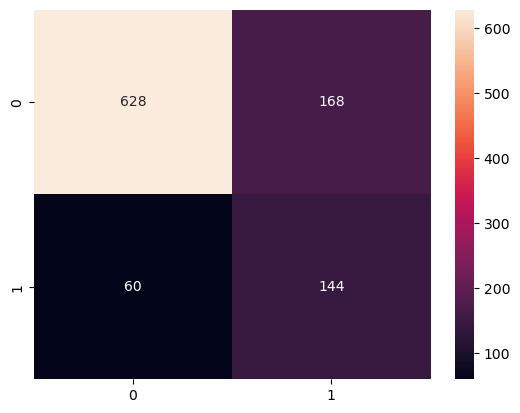

In [105]:
sns.heatmap(confusion_matrix(y_val, predictions), annot=True, fmt="d")

In [106]:
print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

           0       0.91      0.79      0.85       796
           1       0.46      0.71      0.56       204

    accuracy                           0.77      1000
   macro avg       0.69      0.75      0.70      1000
weighted avg       0.82      0.77      0.79      1000



Regularization 

In [107]:
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(13,)),
    # layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    # layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

In [108]:
model.compile(
    optimizer="rmsprop", 
    loss="binary_crossentropy", 
    metrics=["accuracy", keras.metrics.AUC()]
)

In [109]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10
349/349 [==============================] - 1s 2ms/step - loss: 0.5409 - accuracy: 0.7230 - auc_2: 0.8022 - val_loss: 0.4946 - val_accuracy: 0.7550 - val_auc_2: 0.8184
Epoch 2/10
349/349 [==============================] - 1s 2ms/step - loss: 0.4529 - accuracy: 0.7893 - auc_2: 0.8685 - val_loss: 0.4965 - val_accuracy: 0.7540 - val_auc_2: 0.8387
Epoch 3/10
349/349 [==============================] - 0s 1ms/step - loss: 0.4323 - accuracy: 0.8019 - auc_2: 0.8814 - val_loss: 0.4017 - val_accuracy: 0.8060 - val_auc_2: 0.8370
Epoch 4/10
349/349 [==============================] - 0s 1ms/step - loss: 0.4139 - accuracy: 0.8069 - auc_2: 0.8921 - val_loss: 0.5029 - val_accuracy: 0.7630 - val_auc_2: 0.8402
Epoch 5/10
349/349 [==============================] - 0s 1ms/step - loss: 0.4065 - accuracy: 0.8161 - auc_2: 0.8964 - val_loss: 0.4732 - val_accuracy: 0.7760 - val_auc_2: 0.8472
Epoch 6/10
349/349 [==============================] - 1s 2ms/step - loss: 0.3978 - accuracy: 0.8215 - auc_2: 0

Test Prediction

In [110]:
import numpy as np
import seaborn as sns

In [111]:
model.evaluate(X_val, y_val)

32/32 [==============================] - 0s 967us/step - loss: 0.4591 - accuracy: 0.7760 - auc_2: 0.8429


[0.45908406376838684, 0.7760000228881836, 0.8428785800933838]

In [112]:
predictions = model.predict(X_val)

32/32 [==============================] - 0s 862us/step


In [113]:
predictions = np.round(predictions)

In [114]:
from sklearn.metrics import confusion_matrix, classification_report

<AxesSubplot:>

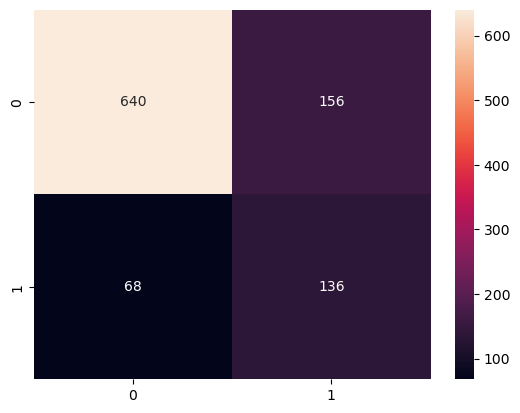

In [115]:
sns.heatmap(confusion_matrix(y_val, predictions), annot=True, fmt="d")

In [116]:
print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85       796
           1       0.47      0.67      0.55       204

    accuracy                           0.78      1000
   macro avg       0.68      0.74      0.70      1000
weighted avg       0.81      0.78      0.79      1000

